In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, List
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.graph.message import add_messages
import operator
from langgraph.checkpoint.memory import MemorySaver # Newer Name: InMemorySaver

In [54]:
load_dotenv()

True

In [55]:
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

In [57]:
class ChatState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]

In [59]:
def chat_node(state: ChatState) -> ChatState:
    messages = state["messages"]
    response = model.invoke(messages)
    return {'messages': [response]}

In [60]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

graph.add_node("Chat Node",chat_node)
graph.add_edge(START, "Chat Node")
graph.add_edge("Chat Node", END)

workflow = graph.compile(checkpointer=checkpointer)

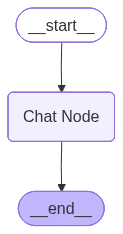

In [61]:
workflow

In [62]:
thread_id = '1'

while True:
    import time
    user_input = input("You: ")
    print(f"User input: {user_input}")
    if user_input.strip().lower() in ["exit", "quit","bye"]:
        break
    config = {'configurable':{'thread_id': thread_id}}
    response = workflow.invoke({"messages": [HumanMessage(content=user_input)]}, config=config)
    print(f"AI: {response['messages'][-1].content}")
    time.sleep(2)

User input: hi myself harsh
AI: Hi Harsh, nice to meet you! How can I help you today?
User input: what is my name
AI: You just told me your name is Harsh! 😊
User input: ok good
AI: Great! I'm glad we're on the same page. What else can I do for you today, Harsh?
User input: exit


In [63]:
workflow.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi myself harsh', additional_kwargs={}, response_metadata={}, id='80cc348b-4807-46e4-93c9-8d6945adf47f'), AIMessage(content='Hi Harsh, nice to meet you! How can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e8e8f-5a7f-7e22-9d89-464974fbd878-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 4, 'output_tokens': 15, 'total_tokens': 19, 'input_token_details': {'cache_read': 0}}), HumanMessage(content='what is my name', additional_kwargs={}, response_metadata={}, id='7639d1a3-dd6b-45e2-838e-dbee24eca637'), AIMessage(content='You just told me your name is Harsh! 😊', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e8e8f-84fb-76f1-9382-cf7